In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn import svm
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
%matplotlib inline

In [3]:
df =pd.read_csv('PandasExample.csv')

In [4]:
df.head()

,FlightID,Date,RouteID,Delay,AircraftID,Scheduled Departure,Avg Ticket Price,Total Fare,Flight Month,Flight Year
0,Flight1,41972,ORD-BOS,3.9,43,0.750000,450.0,74250.0,11,2014
1,Flight2,41967,ORD-JFK,6.8,61,0.791667,375.0,61875.0,11,2014
2,Flight3,42238,ORD-EWR,2.7,72,0.708333,247.5,44797.5,8,2015
3,Flight4,41833,ORD-LAX,3.8,172,0.729167,385.0,63525.0,7,2014
4,Flight5,42135,ORD-IAH,3.0,89,0.708333,200.0,36200.0,5,2015


In [5]:
df.columns

Index(['FlightID', 'Date', 'RouteID', 'Delay', 'AircraftID',
       'Scheduled Departure', 'Avg Ticket Price', 'Total Fare', 'Flight Month',
       'Flight Year'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9636 entries, 0 to 9635
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   FlightID             9636 non-null   object 
 1   Date                 9636 non-null   int64  
 2   RouteID              9636 non-null   object 
 3   Delay                9636 non-null   float64
 4   AircraftID           9636 non-null   int64  
 5   Scheduled Departure  9636 non-null   float64
 6   Avg Ticket Price     9636 non-null   float64
 7   Total Fare           9636 non-null   float64
 8   Flight Month         9636 non-null   int64  
 9   Flight Year          9636 non-null   int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 752.9+ KB


In [7]:
df.isnull().sum()

FlightID               0
Date                   0
RouteID                0
Delay                  0
AircraftID             0
Scheduled Departure    0
Avg Ticket Price       0
Total Fare             0
Flight Month           0
Flight Year            0
dtype: int64

In [8]:
bins =(3,8.5, 20)
group_names= ['bad', 'good']
df['Delay']= pd.cut(df['Delay'], bins= bins, labels = group_names)
df['Delay'].unique()

['bad', NaN, 'good']
Categories (2, object): ['bad' < 'good']

In [9]:
label_quality =LabelEncoder()

In [10]:
df['Delay'] = label_quality.fit_transform(df['Delay'])

In [11]:
df.tail(10)

,FlightID,Date,RouteID,Delay,AircraftID,Scheduled Departure,Avg Ticket Price,Total Fare,Flight Month,Flight Year
9626,Flight9627,42193,ORD-PHX,2,1,0.833333,275.0,50875.0,7,2015
9627,Flight9628,41870,ORD-JFK,2,32,0.833333,275.0,50875.0,8,2014
9628,Flight9629,41725,ORD-SEA,2,146,0.333333,350.0,64750.0,3,2014
9629,Flight9630,42054,ORD-LGA,2,154,0.333333,275.0,45375.0,2,2015
9630,Flight9631,42302,ORD-BOS,2,155,0.770833,300.0,49500.0,10,2015
9631,Flight9632,42146,ORD-DEN,2,85,0.312500,300.0,54300.0,5,2015
9632,Flight9633,41818,ORD-DEN,2,185,0.291667,330.0,54450.0,6,2014
9633,Flight9634,42361,ORD-JFK,0,165,0.708333,350.0,57750.0,12,2015
9634,Flight9635,42188,ORD-MIA,2,201,0.833333,330.0,54450.0,7,2015
9635,Flight9636,42126,ORD-PHX,2,176,0.520833,250.0,41250.0,5,2015


In [12]:
df['Delay'].value_counts()

2    7137
0    1924
1     575
Name: Delay, dtype: int64

<Axes: ylabel='count'>

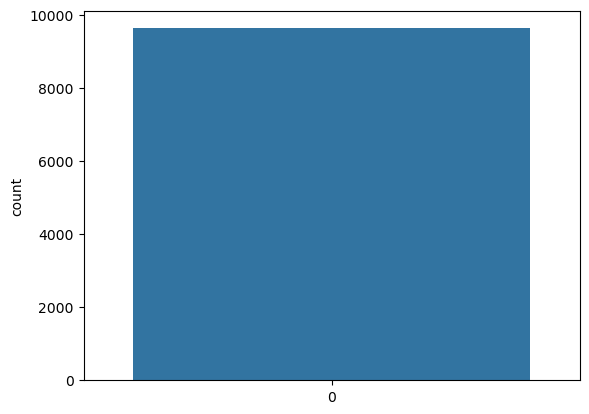

In [13]:
sns.countplot(df['Delay'])

In [14]:
X= df.drop('Delay', axis =1)
y = df['Delay']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state =2)

In [16]:
sc= StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

ValueError: could not convert string to float: 'Flight2847'